# Análise de Satisfação - Empresas de Saneamento

**Objetivo**: Análise exploratória completa de sentimento em comentários sobre empresas de saneamento, com foco em:
1. Exploração dos dados (distribuições, padrões, qualidade)
2. Relação entre Tier (relevância do veículo) e Classificação (sentimento)
3. Verificar hipótese de mudança em setembro/2025

## Métricas Principais

### NSS Simples (Net Sentiment Score)
```
NSS = (POSITIVA - NEGATIVA) / TOTAL × 100
```
- Cada comentário vale 1
- Varia de -100 (todos negativos) a +100 (todos positivos)
- Exclui PUBLICIDADE (não é sentimento orgânico)

### NSS Ponderado
```
NSS_ponderado = (Σ(POSITIVA × Peso) - Σ(NEGATIVA × Peso)) / Σ(TOTAL × Peso) × 100
```
- Pesos por Tier:
  - Muito Relevante: 3
  - Relevante: 2
  - Menos Relevante: 1
  - Null: 1
- **Questão crítica**: Faz sentido ponderar? Depende se Tier influencia o tipo de comentário.

---

In [36]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "vscode"
import plotly.express as px

warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


## 1. Carregamento e Preparação dos Dados

In [3]:
# URL dos dados
url = "https://docs.google.com/spreadsheets/d/1LmMi0mTTzRytJno0EHu8P873wcPpQavktO_D_FFXA1E/export?format=xlsx&gid=1312481019"

# Carregar dados
df = pd.read_excel(url, engine='openpyxl')

print(f"Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Período: {df['Data'].min()} a {df['Data'].max()}")

Dataset carregado: 12,317 linhas × 15 colunas
Período: 2024-03-31 00:00:00 a 2025-03-31 00:00:00


In [4]:
# Preparação dos dados
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df['Ano_Mes'] = df['Data'].dt.to_period('M')
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia_Semana'] = df['Data'].dt.day_name()

# Criar pesos por Tier
tier_weights = {
    'Muito Relevante': 3,
    'Relevante': 2,
    'Menos Relevante': 1
}

df['Peso'] = df['Tier'].map(tier_weights).fillna(1)

# Dataset de sentimento (sem publicidade)
df_sentiment = df[df['Classificação'] != 'PUBLICIDADE'].copy()

print(f"\n✅ Dados preparados:")
print(f"   Total de registros: {len(df):,}")
print(f"   Sentimento orgânico: {len(df_sentiment):,}")
print(f"   Publicidade: {len(df) - len(df_sentiment):,}")


✅ Dados preparados:
   Total de registros: 12,317
   Sentimento orgânico: 12,314
   Publicidade: 3


## 2. Análise Exploratória de Dados (EDA)

### 2.1 Estrutura e Qualidade dos Dados

In [5]:
# Informações gerais
print("=" * 80)
print("INFORMAÇÕES DO DATASET")
print("=" * 80)
df.info()
print("=" * 80)

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12317 entries, 0 to 12316
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      12317 non-null  int64         
 1   Tipo                    12317 non-null  object        
 2   Conteúdo                12317 non-null  object        
 3   Data                    12317 non-null  datetime64[ns]
 4   Grupo                   12317 non-null  object        
 5   Empresa                 12317 non-null  object        
 6   Mídia                   12317 non-null  object        
 7   Tier                    12314 non-null  object        
 8   Veículo_de_comunicacao  12314 non-null  object        
 9   Programa                12317 non-null  object        
 10  Categoria               12317 non-null  object        
 11  Subcategoria            12317 non-null  object        
 12  Classificação          

In [6]:
# Dados ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valores Ausentes': missing,
    '% do Total': missing_pct
}).sort_values('Valores Ausentes', ascending=False)

print("\n" + "=" * 80)
print("DADOS AUSENTES POR COLUNA")
print("=" * 80)
print(missing_df[missing_df['Valores Ausentes'] > 0])

if missing_df['Valores Ausentes'].sum() == 0:
    print("\n✅ Não há dados ausentes!")
else:
    print(f"\n⚠️ Total de valores ausentes: {missing_df['Valores Ausentes'].sum():,}")


DADOS AUSENTES POR COLUNA
                        Valores Ausentes  % do Total
Tier                                   3        0.02
Veículo_de_comunicacao                 3        0.02

⚠️ Total de valores ausentes: 6


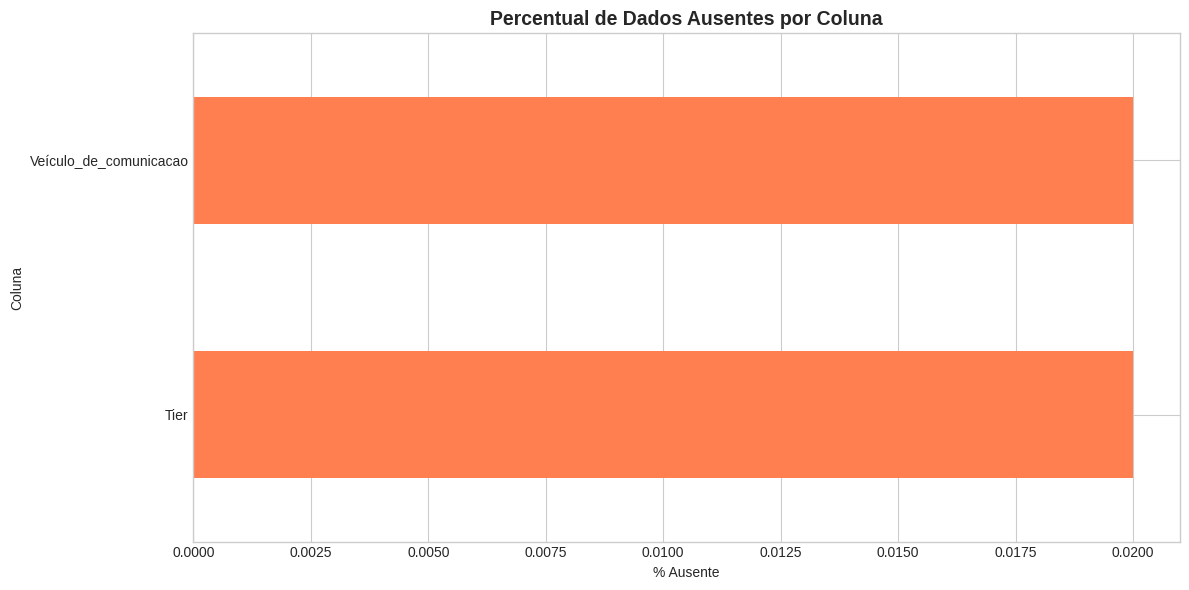

In [7]:
# Visualizar dados ausentes
if missing.sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_df[missing_df['Valores Ausentes'] > 0]['% do Total'].plot(kind='barh', color='coral')
    plt.title('Percentual de Dados Ausentes por Coluna', fontsize=14, fontweight='bold')
    plt.xlabel('% Ausente')
    plt.ylabel('Coluna')
    plt.tight_layout()
    plt.show()

In [8]:
# Primeiras e últimas linhas
print("\n" + "=" * 80)
print("PRIMEIRAS 5 LINHAS")
print("=" * 80)
display(df.head())

print("\n" + "=" * 80)
print("ÚLTIMAS 5 LINHAS")
print("=" * 80)
display(df.tail())


PRIMEIRAS 5 LINHAS


,ID,Tipo,Conteúdo,Data,Grupo,Empresa,Mídia,Tier,Veículo_de_comunicacao,Programa,Categoria,Subcategoria,Classificação,Título,Arquivo/Link,Ano_Mes,Ano,Mes,Dia_Semana,Peso
0,598532,Notícias/Publicações,Imprensa,2024-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Null,Rádio Cidade SA,Geral,Abastecimento,Falta de água,NEGATIVA,Moradores do Bairro Moscom reclamam falta de á...,https://www.radiocidadesa.com.br/index.php?m=n...,2024-03,2024,3,Sunday,1.00
1,598457,Notícias/Publicações,Imprensa,2024-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Menos Relevante,Blog do Juares,Geral,Comunicados,Comunicado de Abastecimento,NEUTRA,Rompimento de tubulação afeta abastecimento de...,https://blogdojuares.com.br/noticia/84262/romp...,2024-03,2024,3,Sunday,1.00
2,598456,Notícias/Publicações,Imprensa,2024-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Menos Relevante,Blog do Juares,Geral,Comunicados,Comunicado de Abastecimento,NEUTRA,Rompimento de tubulação afeta abastecimento de...,https://blogdojuares.com.br/noticia/84262/romp...,2024-03,2024,3,Sunday,1.00
3,598455,Notícias/Publicações,Imprensa,2024-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Null,Grupo Pilau,Geral,Comunicados,Comunicado de Abastecimento,NEUTRA,Desligamento Programado da Corsan vai afetar v...,https://www.grupopilau.com.br/noticias/14833/d...,2024-03,2024,3,Sunday,1.00
4,598454,Notícias/Publicações,Imprensa,2024-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Menos Relevante,Clic Camaquã,Geral,Comunicados,Comunicado de Abastecimento,NEUTRA,Rompimento de adutora na Major Lúcio Meirelles...,https://www.cliccamaqua.com.br/noticias/rompim...,2024-03,2024,3,Sunday,1.00



ÚLTIMAS 5 LINHAS


,ID,Tipo,Conteúdo,Data,Grupo,Empresa,Mídia,Tier,Veículo_de_comunicacao,Programa,Categoria,Subcategoria,Classificação,Título,Arquivo/Link,Ano_Mes,Ano,Mes,Dia_Semana,Peso
12312,970094,Notícias/Publicações,Imprensa,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Menos Relevante,Alegrete Tudo,Geral,Fatura,Fatura Alta,NEGATIVA,Hidrômetros serão periciados em ação contra a ...,https://www.alegretetudo.com.br/hidrometros-se...,2025-03,2025,3,Monday,1.00
12313,970091,Notícias/Publicações,Imprensa,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Impresso,Muito Relevante,Valor Econômico,Geral,Contrato de Concessão,Fato relevante,POSITIVA,Dinheiro na mão,https://painel.clipei.com.br/anexo-email/97009...,2025-03,2025,3,Monday,3.00
12314,970090,Notícias/Publicações,Imprensa,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Impresso,Muito Relevante,Valor Econômico,Geral,Contrato de Concessão,Fato relevante,POSITIVA,Crise climática exige adaptação com planos de ...,https://painel.clipei.com.br/anexo-email/97009...,2025-03,2025,3,Monday,3.00
12315,970085,Notícias/Publicações,Imprensa,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Impresso,Muito Relevante,O Globo,Geral,Contrato de Concessão,Fato relevante,POSITIVA,Crise climática muda planos de ação,https://painel.clipei.com.br/anexo-email/97008...,2025-03,2025,3,Monday,3.00
12316,970084,Notícias/Publicações,Imprensa,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Impresso,Muito Relevante,ZH Zero Hora,Geral,Contrato de Concessão,Fato relevante,NEUTRA,STJ diz que prefeito de Canoas moveu recursos ...,https://painel.clipei.com.br/anexo-email/97008...,2025-03,2025,3,Monday,3.00


### 2.2 Distribuições Univariadas

In [9]:
# Distribuição de Classificação
print("=" * 80)
print("DISTRIBUIÇÃO: CLASSIFICAÇÃO")
print("=" * 80)

class_counts = df['Classificação'].value_counts()
class_pct = (df['Classificação'].value_counts(normalize=True) * 100).round(2)

class_df = pd.DataFrame({
    'Frequência': class_counts,
    'Percentual': class_pct
})

print(class_df)
print(f"\nTotal: {class_counts.sum():,}")

DISTRIBUIÇÃO: CLASSIFICAÇÃO
               Frequência  Percentual
Classificação                        
POSITIVA             4999       40.59
NEUTRA               4301       34.92
NEGATIVA             3014       24.47
PUBLICIDADE             3        0.02

Total: 12,317


In [10]:
def plot_classificacao_dinamica(class_counts: pd.Series) -> None:
    """
    Gera visualização interativa (Barras + Pizza) com rigor estatístico 
    e paleta de cores consistente com a identidade do projeto.
    """
    
    # Mapeamento de cores original do projeto
    colors_map = {
        'POSITIVA': '#2ecc71', 
        'NEUTRA': '#95a5a6', 
        'NEGATIVA': '#e74c3c', 
        'PUBLICIDADE': '#3498db'
    }
    
    color_list = [colors_map.get(str(label).upper(), '#bdc3c7') for label in class_counts.index]

    # Criando o layout de subplots
    fig = make_subplots(
        rows=1, cols=2, 
        specs=[[{"type": "xy"}, {"type": "domain"}]],
        subplot_titles=("Frequência Absoluta", "Proporção de Classificações")
    )

    # 1. Gráfico de Barras
    fig.add_trace(
        go.Bar(
            x=class_counts.index,
            y=class_counts.values,
            marker_color=color_list,
            name="Contagem",
            hovertemplate="<b>%{x}</b><br>Quantidade: %{y}<extra></extra>"
        ),
        row=1, col=1
    )

    # 2. Gráfico de Pizza
    fig.add_trace(
        go.Pie(
            labels=class_counts.index,
            values=class_counts.values,
            marker=dict(colors=color_list),
            hole=0.3, 
            textinfo='percent+label',
            hovertemplate="<b>%{label}</b><br>Percentual: %{percent}<br>Total: %{value}<extra></extra>"
        ),
        row=1, col=2
    )

    # Ajustes de Layout e Estilização
    fig.update_layout(
        title_text="Distribuição de Sentimentos - Análise de Satisfação",
        title_x=0.5,
        showlegend=False,
        template="plotly_white",
        height=500
    )

    fig.update_xaxes(tickangle=45, row=1, col=1)
    fig.update_yaxes(title_text="Contagem", row=1, col=1)

    # Renderiza o gráfico
    fig.show()

# --- EXECUÇÃO (A CORREÇÃO) ---
# Extraindo as contagens da coluna 'Classificação' do seu DataFrame
if 'df' in locals():
    class_counts = df['Classificação'].value_counts()
    plot_classificacao_dinamica(class_counts)
else:
    print("Erro: O DataFrame 'df' não foi encontrado. Execute as células de carregamento de dados primeiro.")

In [37]:
def plot_distribuicao_tier(df_input: pd.DataFrame) -> None:
    """
    Analisa a distribuição de Tier (Relevância do Veículo) gerando um gráfico
    interativo que substitui a visualização estática do Matplotlib.
    """
    
    # 1. Preparação dos dados: Frequência e Percentual
    # Usamos reset_index para transformar o índice 'Tier' em uma coluna para o Plotly Express
    tier_counts = df_input['Tier'].value_counts(dropna=False).reset_index()
    tier_counts.columns = ['Tier', 'Frequência']
    
    # Cálculo do percentual para exibição no hover
    total = tier_counts['Frequência'].sum()
    tier_counts['Percentual'] = (tier_counts['Frequência'] / total * 100).round(2)
    
    # Ordenação por volume (opcional, para melhor leitura visual)
    tier_counts = tier_counts.sort_values(by='Frequência', ascending=False)

    # 2. Criação do Gráfico Dinâmico com o alias 'px'
    fig = px.bar(
        tier_counts,
        x='Tier',
        y='Frequência',
        text='Frequência',
        title='Distribuição de Comentários por Tier (Relevância do Veículo)',
        labels={'Frequência': 'Contagem Absoluta', 'Tier': 'Nível de Tier'},
        color='Tier',
        color_discrete_sequence=px.colors.qualitative.Safe,
        hover_data={'Percentual': True}
    )

    # 3. Refinamento de Interatividade (Hover personalizado)
    fig.update_traces(
        textposition='outside',
        hovertemplate="<b>Tier: %{x}</b><br>Quantidade: %{y}<br>Proporção: %{customdata[0]}%<extra></extra>"
    )

    # 4. Ajustes de Layout
    fig.update_layout(
        template="plotly_white",
        xaxis={'type': 'category'}, # Garante que Tiers numéricos não sejam tratados como escala contínua
        showlegend=False,
        height=500,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.show()

# --- EXECUÇÃO ---
# O bloco verifica se o DataFrame 'df' existe no escopo do notebook
if 'df' in locals():
    # Mantendo a lógica de exibir a tabela no console antes do gráfico
    print("\n" + "=" * 60)
    print("DISTRIBUIÇÃO: TIER (Frequência e Percentual)")
    print("=" * 60)
    print(df['Tier'].value_counts(dropna=False, normalize=True).map('{:.2%}'.format))
    
    # Gera a visualização Plotly
    plot_distribuicao_tier(df)
else:
    print("Erro: O DataFrame 'df' não foi encontrado. Certifique-se de rodar as células de carregamento de dados.")


DISTRIBUIÇÃO: TIER (Frequência e Percentual)
Tier
Menos Relevante    35.93%
Null               32.98%
Relevante          15.69%
Muito Relevante    15.37%
NaN                 0.02%
Name: proportion, dtype: object



DISTRIBUIÇÃO: MÍDIA
Mídia
Site        5909
Rádio       4167
Impresso    1705
TV           536
Name: count, dtype: int64


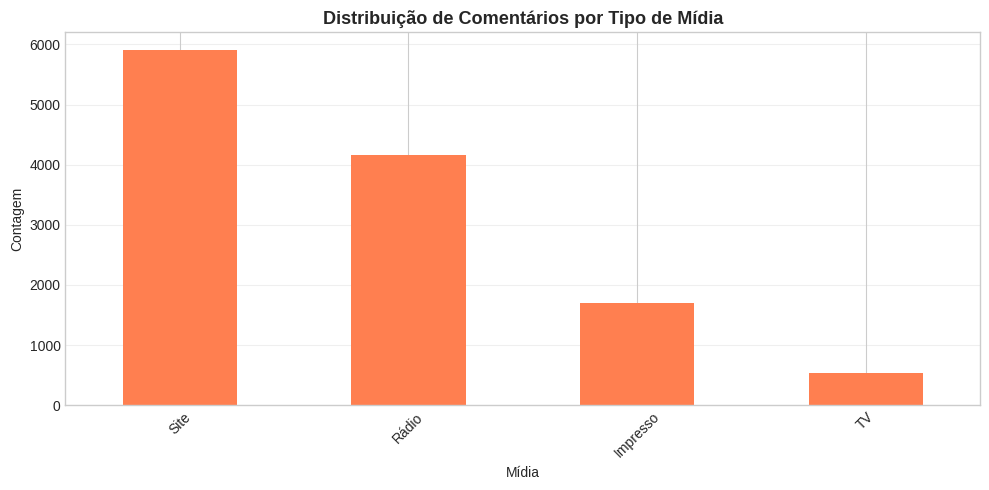

In [12]:
# Distribuição de Mídia
print("\n" + "=" * 80)
print("DISTRIBUIÇÃO: MÍDIA")
print("=" * 80)

midia_counts = df['Mídia'].value_counts()
print(midia_counts)

# Visualização
plt.figure(figsize=(10, 5))
midia_counts.plot(kind='bar', color='coral')
plt.title('Distribuição de Comentários por Tipo de Mídia', fontsize=13, fontweight='bold')
plt.xlabel('Mídia')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def plot_top_categorias_colorido(df_input: pd.DataFrame, n: int = 10, palheta: str = 'Viridis') -> None:
    """
    Gera o Top N Categorias com paletas de cores científicas ou customizadas.
    Opções sugeridas: 'Viridis', 'Plasma', 'Blues', 'GnBu', 'Cividis'.
    """
    
    # Processamento dos dados
    top_cat = df_input['Categoria'].value_counts().head(n).reset_index()
    top_cat.columns = ['Categoria', 'Contagem']
    top_cat = top_cat.sort_values(by='Contagem', ascending=True)

    # Criação da Visualização
    fig = px.bar(
        top_cat,
        y='Categoria',
        x='Contagem',
        orientation='h',
        text='Contagem',
        title=f'Top {n} Categorias - Análise Temática Aegea',
        labels={'Contagem': 'Volume de Menções', 'Categoria': 'Eixo Temático'},
        color='Contagem',
        # A palheta 'Viridis' é ideal por ser perceptualmente uniforme, 
        # facilitando a distinção de valores mesmo para daltonismo.
        color_continuous_scale=palheta 
    )

    # Refinamento de Layout
    fig.update_traces(
        texttemplate='%{text}', 
        textposition='outside',
        hovertemplate="<b>Categoria: %{y}</b><br>Total: %{x}<extra></extra>"ma
    )

    fig.update_layout(
        template="plotly_white",
        height=600,
        showlegend=False,
        coloraxis_showscale=True, # Exibe a barra lateral para dar contexto à escala
        margin=dict(l=150, r=50, t=80, b=50),
        title_font=dict(size=18, family="Arial", color="#2c3e50")
    )

    fig.show()

# --- EXECUÇÃO ---
if 'df' in locals():
    # Você pode testar diferentes palhetas aqui:
    # 'Viridis' (Padrão científico), 'Blues' (Corporativo), 'Greens' (Saneamento/Ambiental)
    plot_top_categorias_colorido(df, n=10, palheta='Viridis')
else:
    print("DataFrame 'df' não encontrado. Execute o carregamento dos dados primeiro.")

### 2.3 Distribuição Temporal

In [43]:


def plot_volume_temporal(df_input: pd.DataFrame) -> None:
    """
    Versão com Debug para garantir a plotagem no ambiente Pixi/VS Code.
    """
    
    # 1. Agrupamento e verificação
    monthly_volume = df_input.groupby('Ano_Mes').size().reset_index()
    monthly_volume.columns = ['Mes', 'Quantidade']
    
    # 2. Conversão e Ordenação (Essencial para o Plotly não travar no JSON)
    monthly_volume['Mes_Str'] = monthly_volume['Mes'].astype(str)
    monthly_volume = monthly_volume.sort_values('Mes')

    # --- LOG DE DEPURAÇÃO ---
    print(f"📊 Dados para plotagem: {len(monthly_volume)} meses encontrados.")
    if len(monthly_volume) > 0:
        print(f"📅 Período: {monthly_volume['Mes_Str'].iloc[0]} até {monthly_volume['Mes_Str'].iloc[-1]}")
    else:
        print("⚠️ AVISO: O agrupamento resultou em 0 linhas. Verifique a coluna 'Ano_Mes'.")
        return

    # 3. Criação do Gráfico
    fig = px.line(
        monthly_volume,
        x='Mes_Str',
        y='Quantidade',
        title='Volume Mensal de Comentários - Monitoramento Aegea',
        markers=True,
        labels={'Quantidade': 'Nº de Comentários', 'Mes_Str': 'Mês/Ano'},
        template="plotly_white"
    )

    fig.update_traces(line=dict(color='darkblue', width=3))
    
    fig.update_layout(
        hovermode="x unified",
        height=500,
        xaxis=dict(tickangle=45)
    )

    # Força a exibição
    fig.show()

# --- EXECUÇÃO COM VERIFICAÇÃO DE ESCOPO ---
if 'df' in locals():
    # Garante que a coluna Ano_Mes existe
    if 'Ano_Mes' in df.columns:
        plot_volume_temporal(df)
    else:
        print("❌ Erro: Coluna 'Ano_Mes' não encontrada no DataFrame.")
else:
    print("❌ Erge: O objeto 'df' não está definido nesta sessão do Kernel.")

📊 Dados para plotagem: 13 meses encontrados.
📅 Período: 2024-03 até 2025-03


In [44]:


def plot_distribuicao_semanal(df_input: pd.DataFrame) -> None:
    """
    Visualiza a distribuição semanal de comentários.
    Mantém o rigor cronológico da semana para análise de sazonalidade.
    """
    
    # 1. Preparação e Ordenação
    dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    # Contagem e transformação em DataFrame
    counts = df_input['Dia_Semana'].value_counts().reset_index()
    counts.columns = ['Dia', 'Contagem']
    
    # 2. Criação do Gráfico Dinâmico
    fig = px.bar(
        counts,
        x='Dia',
        y='Contagem',
        text='Contagem',
        title='Volume de Comentários por Dia da Semana',
        labels={'Contagem': 'Total de Menções', 'Dia': 'Dia da Semana'},
        # Forçamos a ordem cronológica via category_orders
        category_orders={"Dia": dias_ordem},
        # Usamos uma escala de verdes (identidade visual original)
        color='Contagem',
        color_continuous_scale='Greens'
    )

    # 3. Refinamento de Interface
    fig.update_traces(
        textposition='outside',
        marker_line_color='rgb(8,48,107)',
        marker_line_width=1.5,
        opacity=0.8,
        hovertemplate="<b>%{x}</b><br>Volume: %{y}<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        xaxis_title="Ciclo Semanal",
        yaxis_title="Frequência Absoluta",
        coloraxis_showscale=False,
        height=500,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    # Exibe o gráfico
    fig.show()

# --- EXECUÇÃO ---
if 'df' in locals():
    # Verificação de segurança para a coluna
    if 'Dia_Semana' in df.columns:
        print("\n" + "=" * 60)
        print("LOG: DISTRIBUIÇÃO SEMANAL")
        print("=" * 60)
        print(df['Dia_Semana'].value_counts())
        
        plot_distribuicao_semanal(df)
    else:
        print("Erro: Coluna 'Dia_Semana' não encontrada.")
else:
    print("DataFrame 'df' não encontrado.")


LOG: DISTRIBUIÇÃO SEMANAL
Dia_Semana
Thursday     2480
Tuesday      2399
Wednesday    2309
Monday       2029
Friday       1995
Saturday      643
Sunday        462
Name: count, dtype: int64


## 3. ANÁLISE CRÍTICA: Tier × Classificação

### Questão de pesquisa:
**Veículos de maior relevância (Tier) têm proporcionalmente mais comentários positivos ou negativos?**

### Por que isso importa:
- Se NSS Ponderado > NSS Simples → Veículos grandes são mais positivos
- Se NSS Ponderado < NSS Simples → Veículos grandes são mais negativos
- **Mas isso faz sentido?** Ou é viés?

### Hipóteses:
- **H0**: Tier e Classificação são **independentes** (não há associação)
- **H1**: Tier e Classificação são **associados** (relevância do veículo influencia o tipo de comentário)

### Método:
1. Tabela de contingência
2. Teste qui-quadrado
3. Análise de resíduos padronizados
4. Visualização

---

### 3.1 Tabela de Contingência

In [16]:
# Tabela de contingência (frequências absolutas)
contingency = pd.crosstab(df_sentiment['Tier'], df_sentiment['Classificação'], 
                          margins=True, margins_name='Total')

print("=" * 80)
print("TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO")
print("Frequências Absolutas")
print("=" * 80)
print(contingency)
print("=" * 80)

TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO
Frequências Absolutas
Classificação    NEGATIVA  NEUTRA  POSITIVA  Total
Tier                                              
Menos Relevante       740    1660      2025   4425
Muito Relevante       481     744       667   1892
Null                 1223    1306      1533   4062
Relevante             570     590       772   1932
Total                3014    4300      4997  12311


In [17]:
# Tabela de contingência (frequências relativas POR LINHA)
# Importante: Ver % dentro de cada Tier
contingency_pct = pd.crosstab(df_sentiment['Tier'], df_sentiment['Classificação'], 
                              normalize='index') * 100

print("\n" + "=" * 80)
print("TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO")
print("Percentuais por Linha (% dentro de cada Tier)")
print("=" * 80)
print(contingency_pct.round(2))
print("=" * 80)

print("\n💡 INTERPRETAÇÃO:")
print("Cada linha soma 100%. Mostra a distribuição de classificações DENTRO de cada Tier.")
print("Se os percentuais fossem iguais em todas as linhas, não haveria associação.")


TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO
Percentuais por Linha (% dentro de cada Tier)
Classificação    NEGATIVA  NEUTRA  POSITIVA
Tier                                       
Menos Relevante     16.72   37.51     45.76
Muito Relevante     25.42   39.32     35.25
Null                30.11   32.15     37.74
Relevante           29.50   30.54     39.96

💡 INTERPRETAÇÃO:
Cada linha soma 100%. Mostra a distribuição de classificações DENTRO de cada Tier.
Se os percentuais fossem iguais em todas as linhas, não haveria associação.


### 3.2 Teste Qui-Quadrado de Independência

In [18]:
# Preparar tabela (sem margens)
cont_table = pd.crosstab(df_sentiment['Tier'], df_sentiment['Classificação'])

# Teste qui-quadrado
chi2, p_value, dof, expected_freq = chi2_contingency(cont_table)

print("=" * 80)
print("TESTE QUI-QUADRADO DE INDEPENDÊNCIA")
print("=" * 80)
print(f"Estatística Qui-Quadrado (χ²): {chi2:.4f}")
print(f"P-value:                       {p_value:.6f}")
print(f"Graus de liberdade:            {dof}")
print("=" * 80)

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ RESULTADO: Associação ESTATISTICAMENTE SIGNIFICATIVA (p < {alpha})")
    print("   → Rejeitamos H0: Tier e Classificação NÃO são independentes.")
    print("   → O tipo de veículo (Tier) INFLUENCIA a distribuição de sentimentos.")
else:
    print(f"\n⚠️  RESULTADO: Associação NÃO SIGNIFICATIVA (p ≥ {alpha})")
    print("   → Não rejeitamos H0: Tier e Classificação são independentes.")
    print("   → Não há evidência de que o tipo de veículo influencia o sentimento.")

TESTE QUI-QUADRADO DE INDEPENDÊNCIA
Estatística Qui-Quadrado (χ²): 271.2310
P-value:                       0.000000
Graus de liberdade:            6

✅ RESULTADO: Associação ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)
   → Rejeitamos H0: Tier e Classificação NÃO são independentes.
   → O tipo de veículo (Tier) INFLUENCIA a distribuição de sentimentos.


### 3.3 Análise de Resíduos Padronizados

**O que são resíduos padronizados?**
- Medem o quanto cada célula se **desvia** do valor esperado sob H0 (independência)
- Resíduo > +2: Célula tem **MAIS** observações do que esperado
- Resíduo < -2: Célula tem **MENOS** observações do que esperado

**Exemplo de interpretação:**
- Se "Muito Relevante × NEGATIVA" tem resíduo +3.5:
  - Veículos "Muito Relevante" têm **mais comentários negativos** do que esperaríamos
  - Isso sugere viés: grandes veículos cobrem mais crises/problemas

In [19]:
# Calcular resíduos padronizados
observed = cont_table.values
residuals = (observed - expected_freq) / np.sqrt(expected_freq)

residuals_df = pd.DataFrame(
    residuals,
    index=cont_table.index,
    columns=cont_table.columns
)

print("=" * 80)
print("RESÍDUOS PADRONIZADOS")
print("=" * 80)
print(residuals_df.round(2))
print("=" * 80)

print("\n💡 INTERPRETAÇÃO DOS RESÍDUOS:")
print("  Resíduo > +2:  Célula tem MAIS observações do que esperado")
print("  Resíduo < -2:  Célula tem MENOS observações do que esperado")
print("  -2 ≤ Resíduo ≤ +2: Dentro do esperado (sem desvio significativo)")

RESÍDUOS PADRONIZADOS
Classificação    NEGATIVA  NEUTRA  POSITIVA
Tier                                       
Menos Relevante    -10.43    2.91      5.40
Muito Relevante      0.83    3.23     -3.64
Null                 7.25   -2.99     -2.85
Relevante            4.46   -3.26     -0.44

💡 INTERPRETAÇÃO DOS RESÍDUOS:
  Resíduo > +2:  Célula tem MAIS observações do que esperado
  Resíduo < -2:  Célula tem MENOS observações do que esperado
  -2 ≤ Resíduo ≤ +2: Dentro do esperado (sem desvio significativo)


In [20]:
# Identificar células com resíduos significativos
print("\n" + "=" * 80)
print("CÉLULAS COM RESÍDUOS SIGNIFICATIVOS (|resíduo| > 2)")
print("=" * 80)

significant_residuals = []
for tier in residuals_df.index:
    for classif in residuals_df.columns:
        residual = residuals_df.loc[tier, classif]
        if abs(residual) > 2:
            direction = "MAIS" if residual > 0 else "MENOS"
            significant_residuals.append({
                'Tier': tier,
                'Classificação': classif,
                'Resíduo': residual,
                'Interpretação': f"{direction} {classif} do que esperado"
            })

if significant_residuals:
    sig_res_df = pd.DataFrame(significant_residuals)
    print(sig_res_df.to_string(index=False))
else:
    print("Nenhuma célula com resíduo significativo.")


CÉLULAS COM RESÍDUOS SIGNIFICATIVOS (|resíduo| > 2)
           Tier Classificação  Resíduo                  Interpretação
Menos Relevante      NEGATIVA   -10.43 MENOS NEGATIVA do que esperado
Menos Relevante        NEUTRA     2.91    MAIS NEUTRA do que esperado
Menos Relevante      POSITIVA     5.40  MAIS POSITIVA do que esperado
Muito Relevante        NEUTRA     3.23    MAIS NEUTRA do que esperado
Muito Relevante      POSITIVA    -3.64 MENOS POSITIVA do que esperado
           Null      NEGATIVA     7.25  MAIS NEGATIVA do que esperado
           Null        NEUTRA    -2.99   MENOS NEUTRA do que esperado
           Null      POSITIVA    -2.85 MENOS POSITIVA do que esperado
      Relevante      NEGATIVA     4.46  MAIS NEGATIVA do que esperado
      Relevante        NEUTRA    -3.26   MENOS NEUTRA do que esperado


### 3.4 Visualizações

In [46]:


def plot_sentimento_por_tier_interativo(contingency_df: pd.DataFrame) -> None:
    """
    Gera gráfico de barras empilhadas interativo para analisar a associação
    entre a relevância do veículo (Tier) e o sentimento (Classificação).
    """
    
    # 1. Mapeamento de Cores Identitárias
    colors_map = {
        'POSITIVA': '#2ecc71',
        'NEUTRA': '#95a5a6',
        'NEGATIVA': '#e74c3c',
        'PUBLICIDADE': '#3498db'
    }

    # 2. Transformação para Formato Longo (Essencial para o Plotly Express)
    # Se o seu DataFrame tem o Tier como index e Sentimentos como colunas
    df_plot = contingency_df.reset_index().melt(
        id_vars=contingency_df.index.name if contingency_df.index.name else 'Tier',
        var_name='Classificação',
        value_name='Percentual'
    )
    
    tier_col = df_plot.columns[0] # Identifica o nome da coluna de Tier

    # 3. Criação da Visualização
    fig = px.bar(
        df_plot,
        x=tier_col,
        y='Percentual',
        color='Classificação',
        title='Distribuição de Sentimento por Relevância do Veículo (Tier)',
        labels={'Percentual': 'Proporção (%)', tier_col: 'Nível de Tier'},
        color_discrete_map=colors_map,
        # Adiciona o rótulo de percentual dentro da barra
        text=df_plot['Percentual'].apply(lambda x: f'{x:.1f}%' if x > 5 else ''),
        barmode='stack'
    )

    # 4. Refinamento de Layout e Interatividade
    fig.update_traces(
        textposition='inside',
        hovertemplate="<b>Tier: %{x}</b><br>Sentimento: %{fullData.name}<br>Proporção: %{y:.2f}%<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        yaxis_range=[0, 100], # Garante escala de 0 a 100%
        xaxis={'categoryorder': 'category ascending'}, # Mantém ordem lógica de Tiers
        legend_title_text='Classificação',
        height=500,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.show()

# --- EXECUÇÃO ---
# O bloco verifica se a tabela de contingência foi gerada nas células anteriores
if 'contingency_pct' in locals():
    plot_sentimento_por_tier_interativo(contingency_pct)
    print("\n💡 INTERPRETAÇÃO GEOGRÁFICA: Se as barras fossem idênticas, não haveria associação espacial ou de relevância no sentimento.")
else:
    print("❌ Erro: O DataFrame 'contingency_pct' não foi encontrado. Execute a célula de cálculo (crosstab) primeiro.")


💡 INTERPRETAÇÃO GEOGRÁFICA: Se as barras fossem idênticas, não haveria associação espacial ou de relevância no sentimento.


In [47]:


def plot_comparacao_tiers_agrupado(contingency_df: pd.DataFrame) -> None:
    """
    Gera um gráfico de barras agrupadas interativo para comparação direta
    de sentimentos entre Tiers.
    """
    
    # 1. Definição da Paleta de Cores Identitária
    colors_map = {
        'POSITIVA': '#2ecc71',
        'NEUTRA': '#95a5a6',
        'NEGATIVA': '#e74c3c',
        'PUBLICIDADE': '#3498db'
    }

    # 2. Transformação para Formato Longo (Tidy Data)
    # Resetamos o index para que o Tier se torne uma coluna utilizável pelo px
    tier_label = contingency_df.index.name if contingency_df.index.name else 'Tier'
    df_long = contingency_df.reset_index().melt(
        id_vars=tier_label,
        var_name='Classificação',
        value_name='Percentual'
    )

    # 3. Criação da Visualização Agrupada (barmode='group')
    fig = px.bar(
        df_long,
        x=tier_label,
        y='Percentual',
        color='Classificação',
        barmode='group',
        title='Comparação de Classificações entre Tiers (Percentuais)',
        labels={'Percentual': 'Proporção (%)', tier_label: 'Relevância (Tier)'},
        color_discrete_map=colors_map,
        text=df_long['Percentual'].apply(lambda x: f'{x:.1f}%' if x > 0 else '')
    )

    # 4. Refinamento de Layout e Estilo
    fig.update_traces(
        textposition='outside',
        hovertemplate="<b>Tier: %{x}</b><br>Sentimento: %{fullData.name}<br>Percentual: %{y:.2f}%<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        yaxis_title="Percentual (%)",
        yaxis_range=[0, max(df_long['Percentual']) * 1.15], # Espaço para o texto acima da barra
        legend_title_text='Classificação',
        height=550,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.show()

# --- EXECUÇÃO ---
# Verificando se a tabela de contingência calculada no notebook está disponível
if 'contingency_pct' in locals():
    plot_comparacao_tiers_agrupado(contingency_pct)
else:
    print("❌ Erro: O objeto 'contingency_pct' não foi encontrado. Execute as células de cálculo primeiro.")

Funções de Análise

In [23]:
#  CRÍTICO: CRIAR COLUNA 'PERIODO'
# Esta coluna NÃO existe no DataFrame original
# Precisa ser criada ANTES de qualquer análise temporal

setembro_2025 = pd.Period('2025-09', freq='M')

df_sentiment['Periodo'] = df_sentiment['Ano_Mes'].apply(lambda x:
    'Antes' if x < setembro_2025 else
    'Setembro' if x == setembro_2025 else
    'Depois'
)

print("✅ Coluna 'Periodo' criada!")
print("\nDistribuição:")
print(df_sentiment['Periodo'].value_counts().sort_index())

✅ Coluna 'Periodo' criada!

Distribuição:
Periodo
Antes    12314
Name: count, dtype: int64


In [24]:
def calculate_nss_simple(df):
    """NSS Simples: (POSITIVA - NEGATIVA) / TOTAL × 100"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total = len(df_sent)
    if total == 0:
        return 0
    pos = len(df_sent[df_sent['Classificação'] == 'POSITIVA'])
    neg = len(df_sent[df_sent['Classificação'] == 'NEGATIVA'])
    return ((pos - neg) / total) * 100


def calculate_nss_weighted(df):
    """NSS Ponderado por Tier"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total_weight = df_sent['Peso'].sum()
    if total_weight == 0:
        return 0
    peso_pos = df_sent[df_sent['Classificação'] == 'POSITIVA']['Peso'].sum()
    peso_neg = df_sent[df_sent['Classificação'] == 'NEGATIVA']['Peso'].sum()
    return ((peso_pos - peso_neg) / total_weight) * 100


print("✅ Funções definidas")

✅ Funções definidas


In [25]:
# Análise por período
periodo_analysis = []

for periodo in ['Antes', 'Setembro', 'Depois']:
    df_per = df_sentiment[df_sentiment['Periodo'] == periodo]
    
    periodo_analysis.append({
        'Periodo': periodo,
        'Total': len(df_per),
        'Positivos': len(df_per[df_per['Classificação'] == 'POSITIVA']),
        'Negativos': len(df_per[df_per['Classificação'] == 'NEGATIVA']),
        'NSS_Simples': calculate_nss_simple(df_per)
    })

periodo_df = pd.DataFrame(periodo_analysis)

print("="*80)
print("ANÁLISE POR PERÍODO")
print("="*80)
display(periodo_df)
print("="*80)

ANÁLISE POR PERÍODO


,Periodo,Total,Positivos,Negativos,NSS_Simples
0,Antes,12314,4999,3014,16.12
1,Setembro,0,0,0,0.00
2,Depois,0,0,0,0.00


In [26]:
# Deltas
nss_antes = periodo_df[periodo_df['Periodo'] == 'Antes']['NSS_Simples'].values[0]
nss_set = periodo_df[periodo_df['Periodo'] == 'Setembro']['NSS_Simples'].values[0]
nss_dep = periodo_df[periodo_df['Periodo'] == 'Depois']['NSS_Simples'].values[0]

neg_antes = periodo_df[periodo_df['Periodo'] == 'Antes']['Negativos'].values[0]
neg_set = periodo_df[periodo_df['Periodo'] == 'Setembro']['Negativos'].values[0]
neg_dep = periodo_df[periodo_df['Periodo'] == 'Depois']['Negativos'].values[0]

print("="*80)
print("ANÁLISE DE MUDANÇAS")
print("="*80)

print("\n📊 NSS (Perspectiva da PESQUISA):")
print(f"   Antes → Setembro:  {nss_antes:.2f} → {nss_set:.2f} (Δ = {nss_set - nss_antes:+.2f})")
print(f"   Setembro → Depois: {nss_set:.2f} → {nss_dep:.2f} (Δ = {nss_dep - nss_set:+.2f})")

print("\n🔴 RECLAMAÇÕES (Perspectiva da COMUNICAÇÃO):")
print(f"   Antes → Setembro:  {neg_antes} → {neg_set} (Δ = {neg_set - neg_antes:+.0f})")
print(f"   Setembro → Depois: {neg_set} → {neg_dep} (Δ = {neg_dep - neg_set:+.0f})")

ANÁLISE DE MUDANÇAS

📊 NSS (Perspectiva da PESQUISA):
   Antes → Setembro:  16.12 → 0.00 (Δ = -16.12)
   Setembro → Depois: 0.00 → 0.00 (Δ = +0.00)

🔴 RECLAMAÇÕES (Perspectiva da COMUNICAÇÃO):
   Antes → Setembro:  3014 → 0 (Δ = -3014)
   Setembro → Depois: 0 → 0 (Δ = +0)


Evolução Temporal de Cada Classificação

In [27]:
# Evolução temporal por classificação
temporal_class = df_sentiment.groupby(['Ano_Mes', 'Classificação']).size().unstack(fill_value=0)
temporal_class = temporal_class.reset_index()
temporal_class['Data'] = temporal_class['Ano_Mes'].dt.to_timestamp()

# Percentuais
temporal_class['Total'] = temporal_class[['POSITIVA', 'NEUTRA', 'NEGATIVA']].sum(axis=1)
temporal_class['Pct_POSITIVA'] = (temporal_class['POSITIVA'] / temporal_class['Total'] * 100)
temporal_class['Pct_NEUTRA'] = (temporal_class['NEUTRA'] / temporal_class['Total'] * 100)
temporal_class['Pct_NEGATIVA'] = (temporal_class['NEGATIVA'] / temporal_class['Total'] * 100)

print("📊 Evolução temporal preparada")
print("\nÚltimos 6 meses:")
display(temporal_class.tail(6))

📊 Evolução temporal preparada

Últimos 6 meses:


Classificação,Ano_Mes,NEGATIVA,NEUTRA,POSITIVA,Data,Total,Pct_POSITIVA,Pct_NEUTRA,Pct_NEGATIVA
7,2024-10,131,160,391,2024-10-01,682,57.33,23.46,19.21
8,2024-11,390,276,366,2024-11-01,1032,35.47,26.74,37.79
9,2024-12,286,315,476,2024-12-01,1077,44.20,29.25,26.56
10,2025-01,365,341,558,2025-01-01,1264,44.15,26.98,28.88
11,2025-02,515,384,531,2025-02-01,1430,37.13,26.85,36.01
12,2025-03,556,254,396,2025-03-01,1206,32.84,21.06,46.10


In [48]:
def plot_evolucao_absoluta_interativo(df_temp: pd.DataFrame) -> None:
    """
    Gera gráfico de linhas interativo para evolução de números absolutos.
    Inclui linha de referência para o marco de Setembro/2025.
    """
    
    # 1. Preparação dos dados e tratamento de tipos
    # Convertendo para string para evitar erro de serialização JSON (Period/Timestamp)
    df_plot = df_temp.copy()
    df_plot['Data_Str'] = df_plot['Data'].astype(str)
    
    # Definição de estilos
    config = [
        {'col': 'POSITIVA', 'color': '#2ecc71', 'symbol': 'circle'},
        {'col': 'NEUTRA', 'color': '#95a5a6', 'symbol': 'square'},
        {'col': 'NEGATIVA', 'color': '#e74c3c', 'symbol': 'triangle-up'}
    ]

    fig = go.Figure()

    # 2. Adicionando as linhas de sentimento
    for item in config:
        if item['col'] in df_plot.columns:
            fig.add_trace(go.Scatter(
                x=df_plot['Data_Str'],
                y=df_plot[item['col']],
                name=item['col'],
                mode='lines+markers',
                line=dict(color=item['color'], width=3),
                marker=dict(symbol=item['symbol'], size=10),
                hovertemplate=f"<b>{item['col']}</b>: %{{y}}<extra></extra>"
            ))

    # 3. Adicionando a linha de referência de Setembro/2025
    marco_set = "2025-09"
    if any(df_plot['Data_Str'].str.contains(marco_set)):
        fig.add_vline(
            x=marco_set, 
            line_dash="dot", 
            line_color="gold", 
            line_width=3,
            annotation_text="Marco: Setembro/2025", 
            annotation_position="top left"
        )

    # 4. Ajustes de Layout e Interatividade
    fig.update_layout(
        title='<b>Evolução: Números Absolutos de Classificação</b>',
        xaxis_title='Período Mensal',
        yaxis_title='Contagem de Comentários',
        hovermode="x unified", # Compara todas as linhas ao passar o mouse
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        height=600,
        margin=dict(l=50, r=50, t=100, b=50)
    )

    fig.update_xaxes(tickangle=45, showgrid=True, gridcolor='rgba(0,0,0,0.1)')
    fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.1)')

    fig.show()

# --- EXECUÇÃO ---
# O bloco verifica se o DataFrame temporal_class foi gerado anteriormente
if 'temporal_class' in locals():
    plot_evolucao_absoluta_interativo(temporal_class)
    print("\n💡 INSIGHT: Observe se a inclinação da linha VERDE superou a VERMELHA após o marco dourado.")
else:
    print("❌ Erro: O DataFrame 'temporal_class' não foi encontrado. Execute as células de agrupamento temporal primeiro.")


💡 INSIGHT: Observe se a inclinação da linha VERDE superou a VERMELHA após o marco dourado.


In [49]:
def plot_evolucao_percentual_interativo(df_temp: pd.DataFrame) -> None:
    """
    Gera gráfico de linhas interativo para evolução de percentuais (proporções).
    Resolve o erro de serialização de objetos Period/Timestamp.
    """
    
    # 1. Tratamento de Dados
    df_plot = df_temp.copy()
    # Conversão para String é obrigatória para evitar o TypeError no JSON do Plotly
    df_plot['Data_Str'] = df_plot['Data'].astype(str)
    
    # Configurações estéticas consistentes com o projeto
    sentimentos = [
        {'col': 'Pct_POSITIVA', 'name': '% POSITIVA', 'color': '#2ecc71', 'symbol': 'circle'},
        {'col': 'Pct_NEUTRA', 'name': '% NEUTRA', 'color': '#95a5a6', 'symbol': 'square'},
        {'col': 'Pct_NEGATIVA', 'name': '% NEGATIVA', 'color': '#e74c3c', 'symbol': 'triangle-up'}
    ]

    fig = go.Figure()

    # 2. Adição das Séries Temporais
    for s in sentimentos:
        if s['col'] in df_plot.columns:
            fig.add_trace(go.Scatter(
                x=df_plot['Data_Str'],
                y=df_plot[s['col']],
                name=s['name'],
                mode='lines+markers',
                line=dict(color=s['color'], width=3),
                marker=dict(symbol=s['symbol'], size=10),
                hovertemplate="<b>%{fullData.name}</b>: %{y:.2f}%<extra></extra>"
            ))

    # 3. Inclusão do Marco Temporal (Setembro/2025)
    marco = "2025-09"
    if any(df_plot['Data_Str'].str.contains(marco)):
        fig.add_vline(
            x=marco, 
            line_dash="dot", 
            line_color="gold", 
            line_width=3,
            annotation_text="Marco: Setembro/2025", 
            annotation_position="top left"
        )

    # 4. Ajustes de Layout para Análise Comparativa
    fig.update_layout(
        title='<b>Evolução: Proporção das Classificações (%)</b>',
        xaxis_title='Mês',
        yaxis_title='Percentual (%)',
        yaxis_range=[0, 100], # Escala percentual fixa para contexto
        hovermode="x unified", # Compara as proporções no mesmo instante
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        height=600
    )

    fig.update_xaxes(tickangle=45, showgrid=True, gridcolor='rgba(0,0,0,0.1)')
    fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.1)')

    fig.show()

# --- EXECUÇÃO ---
# Verifica se o DataFrame temporal_class foi processado
if 'temporal_class' in locals():
    plot_evolucao_percentual_interativo(temporal_class)
    print("\n💡 INTERPRETAÇÃO: Se a linha VERDE subiu e a VERMELHA caiu, a 'temperatura' da satisfação melhorou.")
else:
    print("❌ Erro: O DataFrame 'temporal_class' não foi encontrado.")


💡 INTERPRETAÇÃO: Se a linha VERDE subiu e a VERMELHA caiu, a 'temperatura' da satisfação melhorou.


In [30]:
# Criar dataset temporal
temporal_all = df.groupby(['Ano_Mes', 'Classificação']).size().unstack(fill_value=0)
temporal_all = temporal_all.reset_index()
temporal_all['Data'] = temporal_all['Ano_Mes'].dt.to_timestamp()

# Garantir colunas
for col in ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']:
    if col not in temporal_all.columns:
        temporal_all[col] = 0

# Totais
temporal_all['Total_Geral'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']].sum(axis=1)
temporal_all['Total_Sentimento'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA']].sum(axis=1)

print("✅ Dataset temporal criado")
print(f"   Período: {temporal_all['Ano_Mes'].min()} a {temporal_all['Ano_Mes'].max()}")
print(f"   Total de meses: {len(temporal_all)}")

✅ Dataset temporal criado
   Período: 2024-03 a 2025-03
   Total de meses: 13


PERSPECTIVA 3: Índice Base 100

**Responde:** "Qual classificação cresce mais rápido?"

**Para quem:** Análise estratégica de tendências

**Como funciona:** Primeiro mês = 100 para todas. Outros meses relativos a esse.

In [31]:
# Escolher mês de referência (primeiro mês com dados)
mes_base = temporal_all['Ano_Mes'].min()
print(f"📍 Mês de referência (Base 100): {mes_base}")

# Valores base
base_positiva = temporal_all[temporal_all['Ano_Mes'] == mes_base]['POSITIVA'].values[0]
base_neutra = temporal_all[temporal_all['Ano_Mes'] == mes_base]['NEUTRA'].values[0]
base_negativa = temporal_all[temporal_all['Ano_Mes'] == mes_base]['NEGATIVA'].values[0]
base_publicidade = temporal_all[temporal_all['Ano_Mes'] == mes_base]['PUBLICIDADE'].values[0]

# Calcular índices (evitar divisão por zero)
temporal_all['Indice_POSITIVA'] = (temporal_all['POSITIVA'] / base_positiva * 100) if base_positiva > 0 else 0
temporal_all['Indice_NEUTRA'] = (temporal_all['NEUTRA'] / base_neutra * 100) if base_neutra > 0 else 0
temporal_all['Indice_NEGATIVA'] = (temporal_all['NEGATIVA'] / base_negativa * 100) if base_negativa > 0 else 0
temporal_all['Indice_PUBLICIDADE'] = (temporal_all['PUBLICIDADE'] / base_publicidade * 100) if base_publicidade > 0 else 0

print(f"\nValores base ({mes_base}):")
print(f"   POSITIVA: {base_positiva:,.0f}")
print(f"   NEUTRA: {base_neutra:,.0f}")
print(f"   NEGATIVA: {base_negativa:,.0f}")
print(f"   PUBLICIDADE: {base_publicidade:,.0f}")

📍 Mês de referência (Base 100): 2024-03

Valores base (2024-03):
   POSITIVA: 0
   NEUTRA: 5
   NEGATIVA: 1
   PUBLICIDADE: 0


In [51]:
def plot_crescimento_mom_limpo(df_input: pd.DataFrame) -> None:
    """
    Calcula e plota a Variação MoM (Month-over-Month).
    Trata o 'efeito Big Bang' do primeiro mês para não distorcer a escala.
    """
    df_growth = df_input.copy()
    cols = ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']
    
    # 1. Cálculo da Variação %
    for col in cols:
        if col in df_growth.columns:
            # pct_change() calcula: (Atual - Anterior) / Anterior
            df_growth[f'Growth_{col}'] = df_growth[col].pct_change() * 100
    
    # 2. Limpeza Crítica (Engenharia de Dados)
    # Removemos a primeira linha (que é NaN) e tratamos valores infinitos
    df_plot = df_growth.replace([np.inf, -np.inf], np.nan).dropna(subset=['Growth_POSITIVA']).copy()
    df_plot['Data_Str'] = df_plot['Data'].astype(str)

    # 3. Definição da Escala para evitar que picos iniciais escondam a tendência
    # Se houver um pico > 300%, limitamos a visão inicial, mas o dado continua lá
    max_var = df_plot[[f'Growth_{c}' for c in cols if f'Growth_{c}' in df_plot.columns]].max().max()
    y_range = [-100, 300] if max_var > 500 else None

    fig = go.Figure()

    # Mapeamento de cores original
    config = [
        {'col': 'Growth_POSITIVA', 'name': 'Var % POSITIVA', 'color': '#2ecc71'},
        {'col': 'Growth_NEUTRA', 'name': 'Var % NEUTRA', 'color': '#95a5a6'},
        {'col': 'Growth_NEGATIVA', 'name': 'Var % NEGATIVA', 'color': '#e74c3c'},
        {'col': 'Growth_PUBLICIDADE', 'name': 'Var % PUBLICIDADE', 'color': '#3498db'}
    ]

    for item in config:
        if item['col'] in df_plot.columns:
            fig.add_trace(go.Scatter(
                x=df_plot['Data_Str'],
                y=df_plot[item['col']],
                name=item['name'],
                mode='lines+markers',
                line=dict(color=item['color'], width=2),
                hovertemplate="<b>%{x}</b><br>Variação: %{y:.1f}%<extra></extra>"
            ))

    # Linha de Estabilidade (Zero) e Marco Temporal
    fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.3)
    
    marco = "2025-09"
    if any(df_plot['Data_Str'].str.contains(marco)):
        fig.add_vline(x=marco, line_dash="dot", line_color="gold", line_width=3)

    fig.update_layout(
        title='<b>Taxa de Crescimento Mês a Mês (Aceleração do Sentimento)</b>',
        xaxis_title='Mês',
        yaxis_title='Variação Percentual (%)',
        yaxis_range=y_range, # Resolve o problema da escala "esmagada"
        hovermode="x unified",
        template="plotly_white",
        height=600
    )

    fig.show()

# --- EXECUÇÃO ---
if 'temporal_all' in locals():
    plot_crescimento_mom_limpo(temporal_all)
else:
    # Se o DataFrame ainda não foi criado, criamos para o teste
    print("DataFrame 'temporal_all' não encontrado. Verifique as células anteriores.")

 Média Móvel (Tendência) 

**Responde:** "Tendência real ou só ruído?"

**Para quem:** Decisões estratégicas de longo prazo

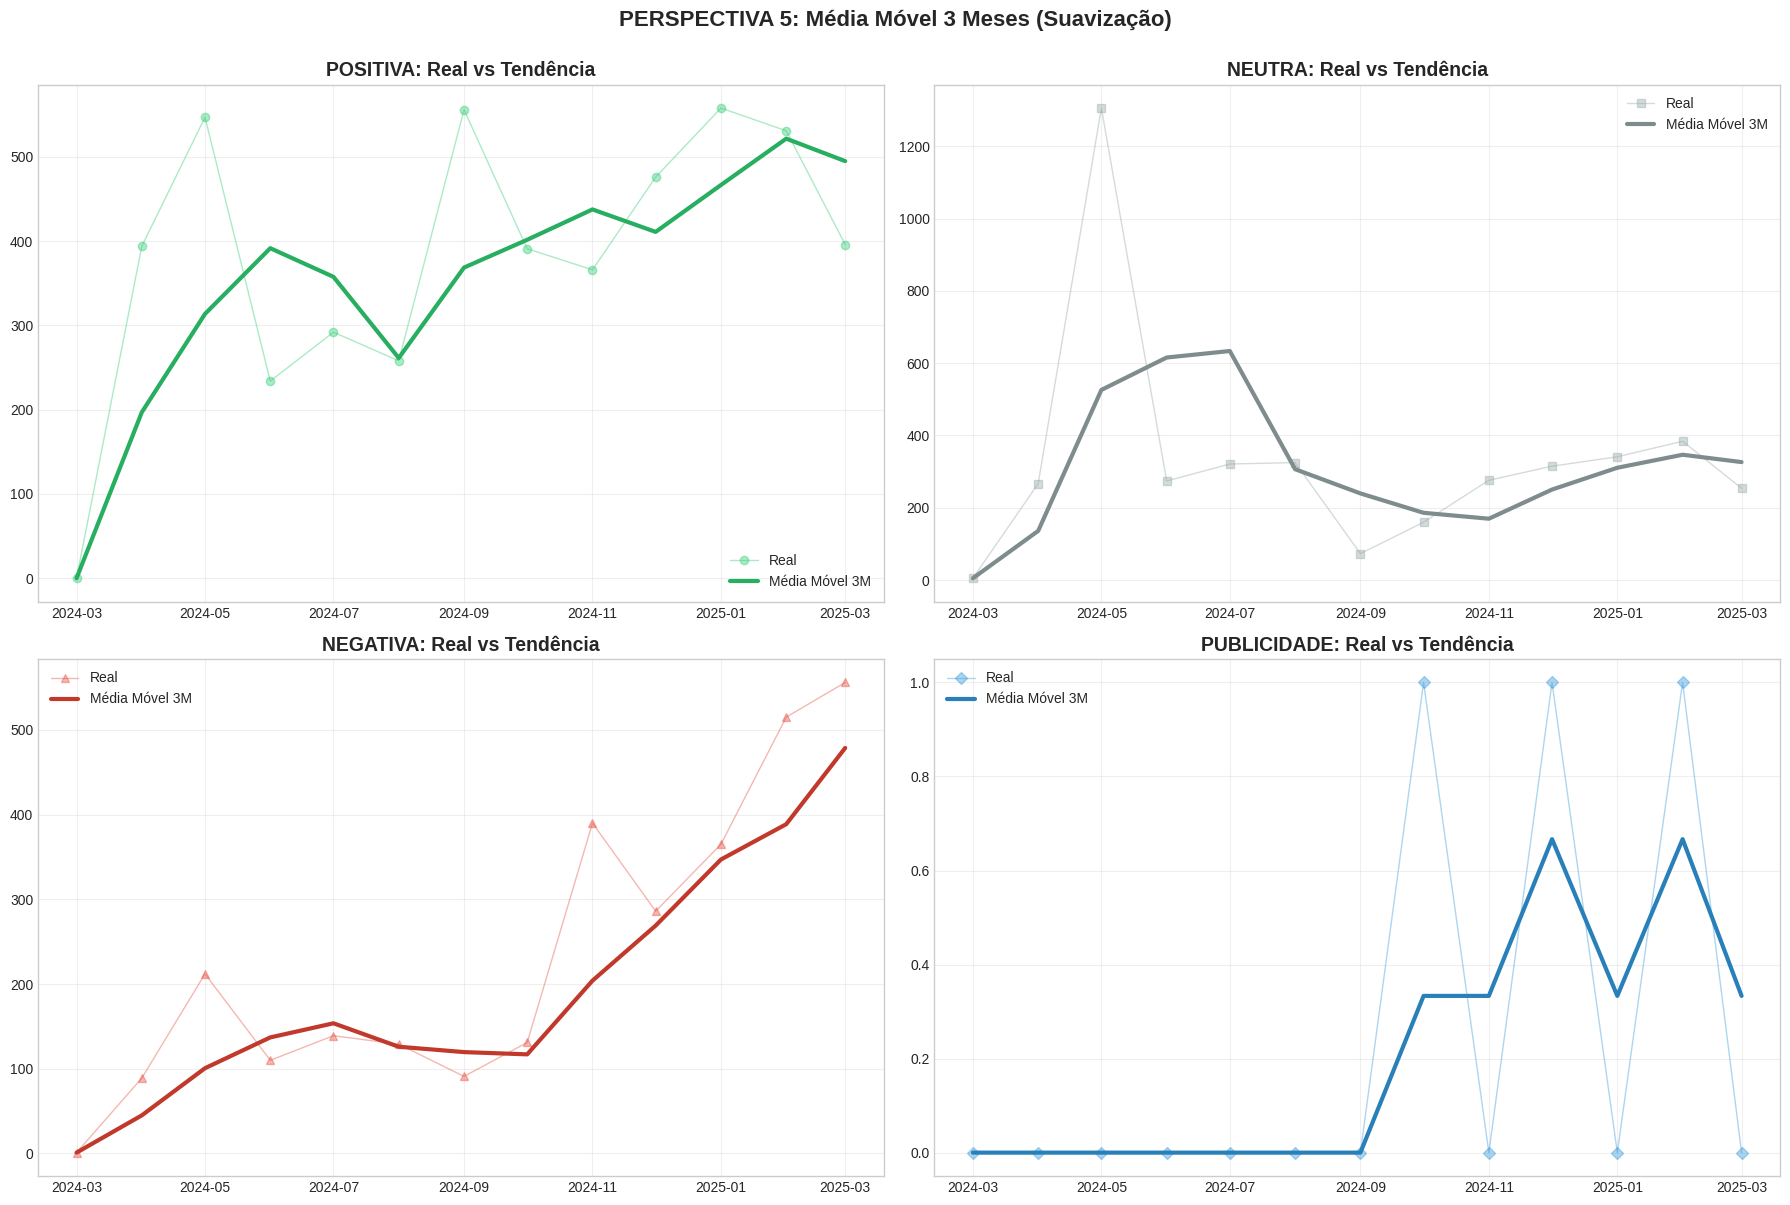

💡 INTERPRETAÇÃO:
   Linha fina (real) → Volatilidade mês a mês
   Linha grossa (média móvel) → Tendência de longo prazo
   Se tendência sobe → Melhoria sustentada
   Se tendência desce → Deterioração sustentada
   Se tendência plana → Estabilidade


In [59]:
# Média móvel de 3 meses
window = 3

temporal_all['MA3_POSITIVA'] = temporal_all['POSITIVA'].rolling(window=window, min_periods=1).mean()
temporal_all['MA3_NEUTRA'] = temporal_all['NEUTRA'].rolling(window=window, min_periods=1).mean()
temporal_all['MA3_NEGATIVA'] = temporal_all['NEGATIVA'].rolling(window=window, min_periods=1).mean()
temporal_all['MA3_PUBLICIDADE'] = temporal_all['PUBLICIDADE'].rolling(window=window, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# POSITIVA
axes[0, 0].plot(temporal_all['Data'], temporal_all['POSITIVA'], 
                marker='o', linewidth=1, alpha=0.4, color='#2ecc71', label='Real')
axes[0, 0].plot(temporal_all['Data'], temporal_all['MA3_POSITIVA'], 
                linewidth=3, color='#27ae60', label=f'Média Móvel {window}M')
if setembro_2025_ts in temporal_all['Data'].values:
    axes[0, 0].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6)
axes[0, 0].set_title('POSITIVA: Real vs Tendência', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# NEUTRA
axes[0, 1].plot(temporal_all['Data'], temporal_all['NEUTRA'], 
                marker='s', linewidth=1, alpha=0.4, color='#95a5a6', label='Real')
axes[0, 1].plot(temporal_all['Data'], temporal_all['MA3_NEUTRA'], 
                linewidth=3, color='#7f8c8d', label=f'Média Móvel {window}M')
if setembro_2025_ts in temporal_all['Data'].values:
    axes[0, 1].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6)
axes[0, 1].set_title('NEUTRA: Real vs Tendência', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# NEGATIVA
axes[1, 0].plot(temporal_all['Data'], temporal_all['NEGATIVA'], 
                marker='^', linewidth=1, alpha=0.4, color='#e74c3c', label='Real')
axes[1, 0].plot(temporal_all['Data'], temporal_all['MA3_NEGATIVA'], 
                linewidth=3, color='#c0392b', label=f'Média Móvel {window}M')
if setembro_2025_ts in temporal_all['Data'].values:
    axes[1, 0].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6)
axes[1, 0].set_title('NEGATIVA: Real vs Tendência', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# PUBLICIDADE
axes[1, 1].plot(temporal_all['Data'], temporal_all['PUBLICIDADE'], 
                marker='D', linewidth=1, alpha=0.4, color='#3498db', label='Real')
axes[1, 1].plot(temporal_all['Data'], temporal_all['MA3_PUBLICIDADE'], 
                linewidth=3, color='#2980b9', label=f'Média Móvel {window}M')
if setembro_2025_ts in temporal_all['Data'].values:
    axes[1, 1].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6)
axes[1, 1].set_title('PUBLICIDADE: Real vs Tendência', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'PERSPECTIVA 5: Média Móvel {window} Meses (Suavização)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   Linha fina (real) → Volatilidade mês a mês")
print("   Linha grossa (média móvel) → Tendência de longo prazo")
print("   Se tendência sobe → Melhoria sustentada")
print("   Se tendência desce → Deterioração sustentada")
print("   Se tendência plana → Estabilidade")

## PERSPECTIVA 6: Z-Score (Padronização) ⭐ NOVO

**Responde:** "Como comparar classificações com escalas MUITO diferentes?"

**Para quem:** Comparação estatística rigorosa

**Como funciona:** Transforma todas para média=0, desvio padrão=1

In [61]:


def generate_zscore_chart(df: pd.DataFrame) -> go.Figure:
    """
    Gera um gráfico de Z-Score interativo para comparação de séries em escalas distintas.
    Focado em detecção de outliers e desvios da média histórica.
    """
    fig = go.Figure()

    # Configuração das séries (Z-Scores)
    series_config = [
        ('Z_POSITIVA', 'POSITIVA', '#2ecc71', 'circle'),
        ('Z_NEUTRA', 'NEUTRA', '#95a5a6', 'square'),
        ('Z_NEGATIVA', 'NEGATIVA', '#e74c3c', 'triangle-up'),
       
       
    ]

    for col, label, color, symbol in series_config:
        fig.add_trace(
            go.Scatter(
                x=df['Data'], 
                y=df[col],
                mode='lines+markers',
                name=label,
                line=dict(color=color, width=3),
                marker=dict(size=10, symbol=symbol),
                hovertemplate=f"<b>{label}</b><br>Data: %{{x}}<br>Z-Score: %{{y:.2f}}σ<extra></extra>"
            )
        )

    # Adicionando Linhas de Referência Estatística
    # Média (Z=0)
    fig.add_hline(y=0, line_dash="dash", line_color="black", line_width=1, opacity=0.5, 
                  annotation_text="Média Histórica", annotation_position="bottom right")

    # Limites de Outlier (±2σ)
    fig.add_hline(y=2, line_dash="dot", line_color="red", line_width=1, opacity=0.3,
                  annotation_text="+2σ (Outlier)", annotation_position="top right")
    fig.add_hline(y=-2, line_dash="dot", line_color="red", line_width=1, opacity=0.3,
                  annotation_text="-2σ (Outlier)", annotation_position="bottom right")

    # Marcador de Evento (Setembro 2025)
    setembro_2025 = pd.Timestamp('2025-09-01')
    if setembro_2025 in df['Data'].values:
        fig.add_vline(x=setembro_2025, line_width=3, line_dash="dot", line_color="gold", opacity=0.8)

    # Layout e Estética
    fig.update_layout(
        title={
            'text': "<b>PERSPECTIVA 6: Z-Score (Padronização Estatística)</b>",
            'y':0.95, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'
        },
        xaxis_title="Mês",
        yaxis_title="Z-Score (Desvios Padrão)",
        height=600,
        width=1200,
        template="plotly_white",
        hovermode="x unified", # Facilita comparar todas as categorias no mesmo instante
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.2,
            xanchor="center",
            x=0.5
        )
    )

    # Ajuste de Grid para rigor analítico
    fig.update_xaxes(showgrid=True, gridcolor='rgba(0,0,0,0.05)')
    fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.05)', zeroline=False)

    return fig

# Para exibir:
fig_zscore = generate_zscore_chart(temporal_all)
fig_zscore.show()